In [1]:
!pip install yfinance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

In [2]:
df = yf.download("AAPL", start="2015-01-01", end="2024-01-01")

data = df[['Close']]

/tmp/ipykernel_9208/1513296246.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


In [3]:

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [4]:
X = []
y = []

for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)

In [5]:
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [6]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [7]:
model = Sequential()

model.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=50))
model.add(Dropout(0.2))

model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - loss: 0.0126
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0025
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - loss: 0.0021
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - loss: 0.0015
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0016
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 0.0016
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0015
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 0.0014
Epoch 9/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - loss: 0.0013
Epoch 10/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - loss: 0.0015


In [9]:
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions.reshape(-1,1))

# Convert y_test back
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step


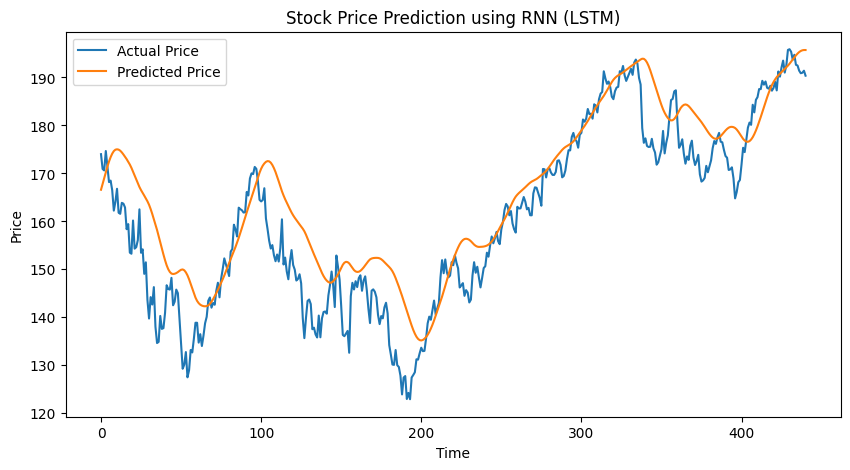

In [10]:
plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.legend()
plt.title("Stock Price Prediction using RNN (LSTM)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

In [11]:
last_60_days = scaled_data[-60:]
last_60_days = np.reshape(last_60_days, (1, 60, 1))

next_day = model.predict(last_60_days)
next_day = scaler.inverse_transform(next_day)

print("Predicted Next Day Price:", next_day[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted Next Day Price: 195.66249
